# Backpropagation

<img src="img/title.png" width="600">

In [1]:
from math import exp, log

import numpy as np
import matplotlib.pyplot as plt
import sympy as sp
from IPython.display import display, Latex
from graphviz import Digraph

<br><br><br>

## Why we need derivatives

We want to minimize a loss function in terms of some model parameters $\ell(p_1, p_2, \ldots, p_{N_p})$.

In general, we'll need a non-linear optimization algorithm.

Some optimization algorithms work with just the function:
* Nelder-Mead simplex
* Powell's method
* Simulated annealing (inspired by cooling metal)
* Genetic algorithms (inspired by biological evolution)
* ...

But algorithms that are given the derivative,

$$ \nabla \ell = \left( \frac{d\ell}{dp_1}, \frac{d\ell}{dp_2}, \ldots, \frac{d\ell}{dp_{N_p}} \right) $$

need to evaluate fewer points $(p_1, p_2, \ldots, p_{N_p})$ to determine the shape of the surface and therefore find the minimum faster.

* Gradient descent
* BFGS, L-BFGS-B
* Adam
* Stochastic gradient descent
* ...

<br><br><br>

<img src="img/downhill.png" width="600">

<br><br><br>

## How computers compute derivatives

* **Symbolic:** like doing calculus by hand
* **Finite differences:** numerical with a "small enough" step size $\Delta p_i$
* **Autodiff:** by propagating each operation using the chain rule

<br><br><br>

## Example of something to differentiate

<img src="img/example.png" width="600">

Activation function:

$$ \sigma(z) = \frac{1}{1 + e^{-z}} $$

First layer:

$$ \begin{aligned}
z_1 &= p_1 \, x_1 + p_4 \, x_2 + p_7 \\
z_2 &= p_2 \, x_1 + p_5 \, x_2 + p_8 \\
z_3 &= p_3 \, x_1 + p_6 \, x_2 + p_9 \\
\end{aligned} $$

Second layer:

$$ \hat{y} = p_{10} \, \sigma(z_1) + p_{11} \, \sigma(z_2) + p_{12} \, \sigma(z_3) + p_{13} $$

Loss is predicted minus target squared:

$$ \ell(p_1, p_2, \ldots p_{13}) = \left( \hat{y} - y \right)^2 $$

<br><br><br>

## Symbolic differentiation

In [2]:
# Symbols
x1, x2, y = sp.symbols("x1 x2 y")
(p1, p2, p3, p4, p5, p6, p7, p8, p9,
 p10, p11, p12, p13) = params = sp.symbols("p1:14")

# Activation function
def sigma(z):
    return 1 / (1 + sp.exp(-z))

# First layer
z1 = p1*x1 + p4*x2 + p7
z2 = p2*x1 + p5*x2 + p8
z3 = p3*x1 + p6*x2 + p9

# Second layer
yhat = p10*sigma(z1) + p11*sigma(z2) + p12*sigma(z3) + p13

# Loss
ell = (yhat - y)**2

# Derivatives d ell / d p_i
derivatives = {
    p_i: sp.simplify(sp.diff(ell, p_i))
    for p_i in params
}

In [3]:
# Print results
for i, deriv in enumerate(derivatives.values()):
    display(Latex(f"$$ \\frac{{d\\ell}}{{dp_{{{i}}}}} = {sp.latex(deriv)} $$"))

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

...

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

<br><br><br>

In [4]:
import random

values = {
    x1: random.uniform(-1, 1),
    x2: random.uniform(-1, 1),
    y: random.uniform(-1, 1),
}
for p_i in params:
    values[p_i] = random.uniform(-1, 1)

print(f"ℓ = {ell.subs(values).evalf():.3f}\n")

for p_i, deriv in derivatives.items():
    print(f"dℓ / d{p_i} = {deriv.subs(values).evalf():.3f}")

ℓ = 1.309

dℓ / dp1 = 0.057
dℓ / dp2 = 0.034
dℓ / dp3 = 0.038
dℓ / dp4 = -0.080
dℓ / dp5 = -0.048
dℓ / dp6 = -0.053
dℓ / dp7 = 0.311
dℓ / dp8 = 0.185
dℓ / dp9 = 0.205
dℓ / dp10 = -1.785
dℓ / dp11 = -1.577
dℓ / dp12 = -1.067
dℓ / dp13 = -2.288

<br><br><br>

This does not scale well to a large number of parameters.

<br><br><br>

## Finite differences

<img src="img/finite-differences.png" width="600">

$$ \frac{d \ell}{d p_i} \approx \frac{\ell(p_i + \Delta p_i) - \ell(p_i)}{\Delta p_i} $$

Or with more precision:

$$ \frac{d \ell}{d p_i} \approx \frac{\ell(p_i + \Delta p_i) - \ell(p_i - \Delta p_i)}{2 \Delta p_i} $$

(The error is quadratic in $\Delta p_i$.)

In [5]:
# Redefine as ordinary numbers, not SymPy

values = {str(k): v for k, v in values.items()}

x1 = values["x1"]
x2 = values["x2"]
y = values["y"]

params = [values[f"p{i+1}"] for i in range(13)]

def sigma(z):
    return 1 / (1 + exp(-z))

In [6]:
def calculate_ell(params):
    (p1, p2, p3, p4, p5, p6, p7, p8, p9,
     p10, p11, p12, p13) = params

    # First layer
    z1 = p1*x1 + p4*x2 + p7
    z2 = p2*x1 + p5*x2 + p8
    z3 = p3*x1 + p6*x2 + p9
    
    # Second layer
    yhat = p10*sigma(z1) + p11*sigma(z2) + p12*sigma(z3) + p13
    
    # Loss
    ell = (yhat - y)**2
    return ell


def derivative_of_ell(params, which):
    low_params = list(params)
    high_params = list(params)

    low_params[which] -= deltapi
    high_params[which] += deltapi

    return (calculate_ell(high_params) - calculate_ell(low_params)) / (2*deltapi)

In [7]:
deltapi = 0.001

print(f"ℓ = {calculate_ell(params):.3f}\n")

for i in range(13):
    print(f"dℓ / dp{i+1} = {derivative_of_ell(params, i):.3f}")

ℓ = 1.309

dℓ / dp1 = 0.057
dℓ / dp2 = 0.034
dℓ / dp3 = 0.038
dℓ / dp4 = -0.080
dℓ / dp5 = -0.048
dℓ / dp6 = -0.053
dℓ / dp7 = 0.311
dℓ / dp8 = 0.185
dℓ / dp9 = 0.205
dℓ / dp10 = -1.785
dℓ / dp11 = -1.577
dℓ / dp12 = -1.067
dℓ / dp13 = -2.288

<br><br><br>

How small should $\Delta p_i$ be?
* Smaller than any of the function's "wiggles."
* Not so small as to encourage round-off error.

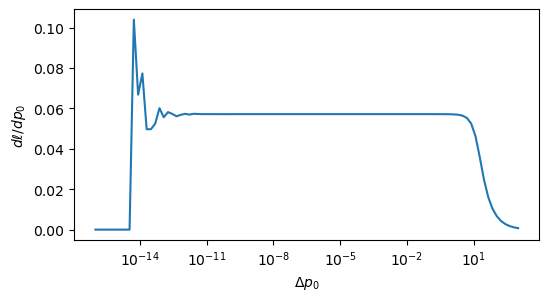

In [8]:
fig, ax = plt.subplots(figsize=(6, 3))

deltapis = 10**np.linspace(-16, 3, 100)

dell_dp0s = []
for deltapi in deltapis:
    dell_dp0s.append(derivative_of_ell(params, 0))

ax.plot(deltapis, dell_dp0s)
ax.set_xscale("log")
ax.set_xlabel("$\\Delta p_0$")
ax.set_ylabel("$d\\ell / dp_0$")

None

<br><br><br>

## Autodiff

Basic idea: push the derivative through every step of the calculation, alongside the function you want to calculate.

<img src="img/autodiff.png" width="600">

**Example:** $f(x) = e^{-x^2}$

We want $f(1.5)$ and also $\frac{df}{dx}$ evaluated at $1.5$.

In [9]:
def square(x, dx):
    return x**2, 2*x*dx

def negate(x, dx):
    return -x, -dx

def exponentiate(x, dx):
    return exp(x), exp(x)*dx

In [10]:
exponentiate(*negate(*square(1.5, 1)))

(0.10539922456186433, -0.316197673685593)

<br><br><br>

**Check:**

In [11]:
symbolic_x = sp.symbols("x")
symbolic_f = sp.exp(-symbolic_x**2)
symbolic_dfdx = sp.diff(symbolic_f)

symbolic_dfdx

-2*x*exp(-x**2)

In [12]:
symbolic_f.subs({symbolic_x: 1.5}), symbolic_dfdx.subs({symbolic_x: 1.5})

(0.105399224561864, -0.316197673685593)

<br><br><br>

**Autodiff** is
* unlike **symbolic differentiation** because we don't construct an expression for the derivative everywhere, only at the point of interest,
* unlike **finite differences** because it doesn't rely on a "small enough but not too small" step.

<br><br><br>

## Relevance of the chain rule

**Statement of the chain rule:** If $z$ depends on $y$ and $y$ depends on $x$, and we want $\frac{dz}{dx}$,

$$ \frac{dz}{dx} = \frac{dz}{dy} \cdot \frac{dy}{dx} $$

<br><br>

**Another illustration:** Using the $f'$ notation for derivative,

$$ \bigg[f\bigg(g\big(h(x)\big)\bigg)\bigg]' =
f'\bigg(g\big(h(x)\big)\bigg) \cdot g'\big(h(x)\big) \cdot h'(x) \cdot 1 $$

<br><br>

**Intuition:** Derivative of function composition → multiplication by the composed part. Note that the chain ends in $1$.

Autodiff propagates derivatives through code, so every operation is an application of the chain rule.

<br><br><br>

## Implementing autodiff

`Dual` represents the value of a function and its derivative, which get computed together.

In [22]:
class Dual:
    def __init__(self, x, dx):
        self.x = x
        self.dx = dx

    def __repr__(self):
        return f"Dual({self.x}, {self.dx})"

    @staticmethod
    def ensure_dual(value):
        if isinstance(value, Dual):
            return value
        else:
            return Dual(value, 0)  # 0 → assumes no dependence

    def __neg__(self):
        return Dual(
            -self.x,
            -self.dx,
        )
    
    def __add__(self, other):
        other = Dual.ensure_dual(other)
        return Dual(
            self.x + other.x,
            self.dx + other.dx,
        )
    def __radd__(self, other):
        return self + other

    def __sub__(self, other):
        other = Dual.ensure_dual(other)
        return Dual(
            self.x - other.x,
            self.dx - other.dx,
        )
    def __rsub__(self, other):
        return self - other

    def __mul__(self, other):
        other = Dual.ensure_dual(other)
        return Dual(
            self.x * other.x,
            self.dx * other.x + self.x * other.dx,
        )
    def __rmul__(self, other):
        return self * other

    def __truediv__(self, other):
        other = Dual.ensure_dual(other)
        return Dual(
            self.x / other.x,
            (self.dx * other.x - self.x * other.dx) / other.x**2,
        )
    def __rtruediv__(self, other):
        other = Dual.ensure_dual(other)
        return other / self

    def __pow__(self, other):
        other = Dual.ensure_dual(other)
        return Dual(
            self.x ** other.x,
            self.x ** other.x * (
                other.dx * log(self.x) + other.x * self.dx / self.x
            ),
        )
    def __rpow__(self, base):
        base = Dual.ensure_dual(base)
        return base ** self

    @staticmethod
    def exp(dual):
        dual = Dual.ensure_dual(dual)
        return Dual(
            exp(dual.x),
            exp(dual.x) * dual.dx,
        )

Now let's return to our standard differentiation problem.

<img src="img/example.png" width="600">

In [23]:
def calculate_ell(x1, x2, y, params):
    (p1, p2, p3, p4, p5, p6, p7, p8, p9,
     p10, p11, p12, p13) = params

    # Activation function
    def sigma(z):
        return 1 / (1 + Dual.exp(-z))
    
    # First layer
    z1 = p1*x1 + p4*x2 + p7
    z2 = p2*x1 + p5*x2 + p8
    z3 = p3*x1 + p6*x2 + p9
    
    # Second layer
    yhat = p10*sigma(z1) + p11*sigma(z2) + p12*sigma(z3) + p13

    tmp = yhat - y
    
    print(tmp)
    
    # Loss
    ell = (tmp)**2
    return ell

In [24]:
# The given data are constants
x1 = Dual(values["x1"], 0)
x2 = Dual(values["x2"], 0)
y = Dual(values["y"], 0)

for i in range(13):
    # Differentiate with respect to one of the parameters
    params = [
        Dual(values[f"p{j+1}"], 1 if i == j else 0)
        for j in range(13)
    ]

    dual = calculate_ell(x1, x2, y, params)
    print(f"ℓ = {dual.x:.3f}, dℓ / dp{i+1} = {dual.dx:.3f}")

Dual(-1.1441881556931386, -0.024997283469628807)

ValueError: math domain error

<br><br><br>

This is **forward propagation** autodiff: each real number is replaced by a dual number
* with `dx=0` if we are not differentiating with respect to that variable,
* with `dx=1` if we are.

In order to get all of the components of

$$ \nabla \ell = \left( \frac{d\ell}{dp_1}, \frac{d\ell}{dp_2}, \ldots, \frac{d\ell}{dp_{N_p}} \right) $$

we had to compute the full expression $N_p$ times.

This does not scale well to a large number of parameters.

<br><br><br>

**Backpropagation** is a performance enhancement. By changing the order of the calculation and caching partial results, it avoids unnecessary recomputation.

<br><br><br>

## Avoiding recomputation: Fibonacci sequence

<img src="img/fibonacci.png" width="600">

In [ ]:
def fibonacci(n):
    print(f"calculating fibonacci({n})")
    if n == 0:
        return 0
    elif n == 1:
        return 1
    else:
        return fibonacci(n - 1) + fibonacci(n - 2)

In [ ]:
for n in range(10):
    print(fibonacci(n))

In [ ]:
cache = {}

def fibonacci(n):
    if n in cache:
        return cache[n]
    print(f"calculating fibonacci({n})")
    if n == 0:
        cache[n] = 0
    elif n == 1:
        cache[n] = 1
    else:
        cache[n] = fibonacci(n - 1) + fibonacci(n - 2)
    return cache[n]

In [ ]:
for n in range(10):
    print(fibonacci(n))

<br><br><br>

## Backpropagation

**Strategy:**
* The function will be calculated forward (the normal way), saving each intermediate result.
* The derivative will be calculated from the from the function output to its inputs (backward).

We will need additional infrastructure to do this, similar to the Fibonacci cache. We will need a **computation graph**.

<img src="img/computation-graph.png" width="600">

`Node` represents a node on the graph with its incoming and outgoing edges.

In [ ]:
class Node:
    def __init__(self, name, inputs=()):
        self.name = name
        self.inputs = list(inputs)
        self.outputs = []

        for node in self.inputs:
            node.outputs.append(self)

        self.value = None
        self.grad = None

    def forward(self, *args):
        return self.value

    def backward(self, *args):
        return []

# Later, we'll need different types of graph nodes, but not yet

class ConstNode(Node):
    pass

class VarNode(Node):
    pass

class NegNode(Node):
    pass

class AddNode(Node):
    pass

class SubNode(Node):
    pass

class MulNode(Node):
    pass

class DivNode(Node):
    pass

class PowNode(Node):
    pass

class ExpNode(Node):
    pass

`Tracer` walks through an expression accumulating a graph structure, rather than computing the expression.

In [ ]:
class Tracer:
    def __init__(self, node):
        self.node = node

    @staticmethod
    def constant(name):
        return Tracer(ConstNode(name))

    @staticmethod
    def variable(name):
        return Tracer(VarNode(name))

    @staticmethod
    def ensure_tracer(x):
        if isinstance(x, Tracer):
            return x
        else:
            out = Tracer.constant(repr(x))
            out.node.value = x
            return out

    def __neg__(self):
        return Tracer(NegNode("neg", [self.node]))

    def __add__(self, other):
        other = Tracer.ensure_tracer(other)
        return Tracer(AddNode("+", [self.node, other.node]))
    def __radd__(self, other):
        return Tracer.ensure_tracer(other) + self

    def __sub__(self, other):
        other = Tracer.ensure_tracer(other)
        return Tracer(SubNode("‒", [self.node, other.node]))
    def __rsub__(self, other):
        return Tracer.ensure_tracer(other) - self

    def __mul__(self, other):
        other = Tracer.ensure_tracer(other)
        return Tracer(MulNode("×", [self.node, other.node]))
    def __rmul__(self, other):
        return Tracer.ensure_tracer(other) * self

    def __truediv__(self, other):
        other = Tracer.ensure_tracer(other)
        return Tracer(DivNode("÷", [self.node, other.node]))
    def __rtruediv__(self, other):
        return Tracer.ensure_tracer(other) / self

    def __pow__(self, other):
        other = Tracer.ensure_tracer(other)
        return Tracer(PowNode("↑", [self.node, other.node]))
    def __rpow__(self, other):
        return Tracer.ensure_tracer(other) ** self

    @staticmethod
    def exp(x):
        x = Tracer.ensure_tracer(x)
        return Tracer(ExpNode("exp", [x.node]))

`topological_sort` puts the nodes in dependency order: which nodes have to be computed before which other ones?

In [ ]:
def topological_sort(output_node):
    visited = set()
    order = []

    def visit(node):
        if id(node) in visited:
            return
        visited.add(id(node))

        for input_node in node.inputs:
            visit(input_node)

        order.append(node)

    visit(output_node)
    return order

This is for visualizing the graph.

In [ ]:
def visualize(tracer):
    order = topological_sort(tracer.node)

    dot = Digraph()

    for node in order:
        label = node.name
        if node.value is not None and repr(node.value) != node.name:
            label += f" | {node.value:.3f}"
        dot.node(str(id(node)), label=label, shape="box")

    for node in order:
        for input_node in node.inputs:
            dot.edge(str(id(input_node)), str(id(node)))

    return dot

Now let's return to our standard differentiation problem.

<img src="img/example.png" width="600">

In [ ]:
# Constants and variables
x1 = Tracer.constant("x1")
x2 = Tracer.constant("x2")
y = Tracer.constant("y")

(
    p1, p2, p3, p4, p5, p6, p7, p8, p9, p10, p11, p12, p13
) = [Tracer.variable(f"p{i+1}") for i in range(13)]

# Activation function
def sigma(z):
    return 1 / (1 + Tracer.exp(-z))

# First layer
z1 = p1*x1 + p4*x2 + p7
z2 = p2*x1 + p5*x2 + p8
z3 = p3*x1 + p6*x2 + p9

# Second layer
yhat = p10*sigma(z1) + p11*sigma(z2) + p12*sigma(z3) + p13

# Loss
ell = (yhat - y)**2

In [ ]:
visualize(ell)

<br><br><br>

Now let's set up the graph for a forward computation. This will compute the function value and cache all the intermediate steps along the way.

First, the constants ($x_1$, $x_2$, $y$) and variables ($p_1$ through $p_{13}$) need to be given their values.

In [ ]:
x1.node.value = values["x1"]
x2.node.value = values["x2"]
y.node.value = values["y"]

p1.node.value = values["p1"]
p2.node.value = values["p2"]
p3.node.value = values["p3"]
p4.node.value = values["p4"]
p5.node.value = values["p5"]
p6.node.value = values["p6"]
p7.node.value = values["p7"]
p8.node.value = values["p8"]
p9.node.value = values["p9"]
p10.node.value = values["p10"]
p11.node.value = values["p11"]
p12.node.value = values["p12"]
p13.node.value = values["p13"]

Next, each type of node needs to know how to perform its computation.

In [ ]:
NegNode.forward = lambda self, x: -x
AddNode.forward = lambda self, x, y: x + y
SubNode.forward = lambda self, x, y: x - y
MulNode.forward = lambda self, x, y: x * y
DivNode.forward = lambda self, x, y: x / y
PowNode.forward = lambda self, x, y: x ** y
ExpNode.forward = lambda self, x: exp(x)

The forward pass starts with constants and variables, whose values are known, and fills in values for the rest of the graph.

In [ ]:
def forward(tracer):
    order = topological_sort(tracer.node)
    
    for node in order:
        input_values = [input_node.value for input_node in node.inputs]
        node.value = node.forward(*input_values)

forward(ell)

Now every node knows the value of the computation up to that point, including the last node, which is the final result.

In [ ]:
visualize(ell)

<br><br><br>

Each node type needs to know how to propagate derivatives (`grad`) to its inputs.

In [ ]:
NegNode.backward = lambda self, grad, x: [-grad]
AddNode.backward = lambda self, grad, x, y: [grad, grad]
SubNode.backward = lambda self, grad, x, y: [grad, -grad]
MulNode.backward = lambda self, grad, x, y: [grad * y, grad * x]
DivNode.backward = lambda self, grad, x, y: [grad / y, -grad * x / y**2]
PowNode.backward = lambda self, grad, x, y: [grad * y * x**(y - 1), grad * x**y * log(x)]
ExpNode.backward = lambda self, grad, x: [grad * exp(x)]

The backward pass starts by setting `grad = 1` on the result and traverses toward the constants and variables, propagating the derivative's contribution at each step.

In [ ]:
def backward(tracer):
    order = topological_sort(tracer.node)

    for node in order:
        node.grad = 0

    tracer.node.grad = 1

    for node in reversed(order):
        input_values = [input_node.value for input_node in node.inputs]
        input_grads = node.backward(node.grad, *input_values)

        for input_node, input_grad in zip(node.inputs, input_grads):
            input_node.grad += input_grad

backward(ell)

When it's done, we can read the derivatives off the variable nodes.

In [ ]:
print(f"dℓ / dp1 = {p1.node.grad:.3f}")
print(f"dℓ / dp2 = {p2.node.grad:.3f}")
print(f"dℓ / dp3 = {p3.node.grad:.3f}")
print(f"dℓ / dp4 = {p4.node.grad:.3f}")
print(f"dℓ / dp5 = {p5.node.grad:.3f}")
print(f"dℓ / dp6 = {p6.node.grad:.3f}")
print(f"dℓ / dp7 = {p7.node.grad:.3f}")
print(f"dℓ / dp8 = {p8.node.grad:.3f}")
print(f"dℓ / dp9 = {p9.node.grad:.3f}")
print(f"dℓ / dp10 = {p10.node.grad:.3f}")
print(f"dℓ / dp11 = {p11.node.grad:.3f}")
print(f"dℓ / dp12 = {p12.node.grad:.3f}")
print(f"dℓ / dp13 = {p13.node.grad:.3f}")